# Experiment 6 — Principled L1 and learning-rate sweeps for a StandardTraining SAE

This notebook isolates the two optimization choices most likely to change primitive
recovery in the difficult `N=256` orthogonal-antipodal setting:

- **Experiment 6A:** vary only the L1 coefficient while holding learning rate at
  the project baseline `3e-4`;
- **Experiment 6B:** after 6A is complete, use its selected L1 coefficient and vary
  only the learning rate.

Every full candidate trains a fresh SAELens `StandardTrainingSAE` on exactly
**125,000,000 generated activations**. The primary outcomes are Mean Max Cosine
Similarity (MMCS) and one-to-one Hungarian primitive recovery at cosine `>= 0.90`.

The non-swept SAE/trainer settings are the fixed project baseline used by Experiments
3 and 4. The same dictionary, data seed, and SAE initialization seed are reused across
candidates so that the changed hyperparameter is the only intended source of
between-condition variation. This is a controlled single-seed comparison, not an
estimate of uncertainty across random initializations.


## Experimental contract

Experiment 6A uses an expanded 20-value L1 grid from `0.001` through `0.3`:

`0.001, 0.002, 0.003, 0.005, 0.0075, 0.01, 0.015, 0.02, 0.03, 0.05,`
`0.075, 0.1, 0.125, 0.15, 0.175, 0.2, 0.225, 0.25, 0.275, 0.3`.

The grid retains all 10 completed 6A values, adds two lower-tail values, and adds
eight values above the former best/upper boundary of `0.1`. Exact completed rows
and checkpoints are reused; the same 6A result, ranking, plot, and selection files
are overwritten with the expanded sweep.

Experiment 6B uses the requested 10-value learning-rate grid:

`1e-4, 1.5e-4, 2e-4, 3e-4, 4e-4, 5e-4, 6e-4, 7.5e-4, 1e-3, 1.5e-3`.

Exactly one SAE seed (`SAE_SEED = 0`) is trained for every condition. There is no
multi-seed aggregation or confidence interval in either experiment.

Both metrics lie in `[0, 1]`, so the automatic 6A recommendation maximizes their
equal-weight mean. The result table also marks the Pareto-optimal L1 settings. Ties
are broken by Hungarian 90%, then MMCS, then proximity to the baseline L1. You may
inspect the 6A CSV/plot and set `SELECTED_L1_OVERRIDE` before running 6B.

The 6B cell refuses to train until a complete full-mode 6A result table and selection
manifest exist. Completed candidate models and result rows are reused on rerun.


## Environment setup (local or Google Colab)

Run the next cell before any imports. Locally, it finds the existing checkout and
does not clone, pull, or install packages. In Google Colab it uses `/content/SAE`,
clones the GitHub repository when absent, safely fast-forwards a clean existing clone,
and installs `composed-features/requirements.txt`. Google Drive is never mounted.

All checkpoints, CSV/JSON results, and PNG plots are written inside the cloned
checkout at
`composed-features/artifacts/06_standard_sae_hyperparameter_sweeps/`. Colab's
`/content` storage is runtime-local, so download or commit new artifacts before
resetting the runtime if they must persist.


In [1]:
from __future__ import annotations

import importlib.util
import os
import subprocess
import sys
from pathlib import Path


try:
    IN_COLAB = importlib.util.find_spec('google.colab') is not None
except ModuleNotFoundError:
    IN_COLAB = False
INSTALL_REQUIREMENTS = IN_COLAB
UPDATE_EXISTING_COLAB_REPOSITORY = True
COLAB_REPOSITORY_URL = 'https://github.com/Adefioye/SAE.git'
COLAB_REPOSITORY_ROOT = Path('/content/SAE')


def find_experiment_dir(start: Path) -> Path | None:
    candidates = (start, start / 'composed-features')
    return next(
        (path for path in candidates
         if (path / 'sparse_factorial_generator.py').is_file()),
        None,
    )


if IN_COLAB:
    repository_root = COLAB_REPOSITORY_ROOT
    EXPERIMENT_DIR = find_experiment_dir(repository_root)
    if EXPERIMENT_DIR is None:
        if repository_root.exists() and any(repository_root.iterdir()):
            raise FileExistsError(
                f'{repository_root} exists but is not the SAE repository. '
                'Move that directory or choose a different clone path.'
            )
        repository_root.parent.mkdir(parents=True, exist_ok=True)
        subprocess.run(
            [
                'git', 'clone', '--depth', '1',
                COLAB_REPOSITORY_URL, str(repository_root),
            ],
            check=True,
        )
    elif UPDATE_EXISTING_COLAB_REPOSITORY:
        git_directory = repository_root / '.git'
        if git_directory.is_dir():
            repository_status = subprocess.run(
                ['git', '-C', str(repository_root), 'status', '--porcelain'],
                check=True, capture_output=True, text=True,
            ).stdout.strip()
            if repository_status:
                print('Existing Colab clone has local changes; skipping pull.')
            else:
                subprocess.run(
                    ['git', '-C', str(repository_root), 'pull', '--ff-only'],
                    check=True,
                )
        else:
            print('Existing project is not a Git clone; skipping pull.')
    EXPERIMENT_DIR = find_experiment_dir(repository_root)
else:
    EXPERIMENT_DIR = find_experiment_dir(Path.cwd().resolve())

if EXPERIMENT_DIR is None:
    raise FileNotFoundError(
        'Could not find composed-features/sparse_factorial_generator.py. '
        'Run locally from the repository root/composed-features directory, '
        'or verify the Colab repository URL.'
    )

EXPERIMENT_DIR = EXPERIMENT_DIR.resolve()
REQUIREMENTS_PATH = EXPERIMENT_DIR / 'requirements.txt'
if not REQUIREMENTS_PATH.is_file():
    raise FileNotFoundError(f'Missing requirements file: {REQUIREMENTS_PATH}')

if INSTALL_REQUIREMENTS:
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install',
        '--upgrade-strategy', 'only-if-needed',
        '-r', str(REQUIREMENTS_PATH),
    ])

os.chdir(EXPERIMENT_DIR)
print('Runtime:', 'Google Colab' if IN_COLAB else 'local Jupyter')
print('Experiment directory:', EXPERIMENT_DIR)
print('Requirements installed:', INSTALL_REQUIREMENTS)
if IN_COLAB:
    print('Colab storage: /content runtime-local (Google Drive is not used)')


Runtime: local Jupyter
Experiment directory: /Users/abdulhakeemadefioye/Desktop/SAE/composed-features
Requirements installed: False


In [2]:
import json
import math
import platform
import sys
from collections.abc import Sequence
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import scipy
import torch
import torch.nn.functional as F
from IPython.display import Image, display
from scipy.optimize import linear_sum_assignment
from tqdm.auto import tqdm


if 'EXPERIMENT_DIR' not in globals():
    working_dir = Path.cwd().resolve()
    if (working_dir / 'sparse_factorial_generator.py').is_file():
        EXPERIMENT_DIR = working_dir
    elif (working_dir / 'composed-features' / 'sparse_factorial_generator.py').is_file():
        EXPERIMENT_DIR = working_dir / 'composed-features'
    else:
        raise FileNotFoundError('Run the Environment setup cell first.')
EXPERIMENT_DIR = Path(EXPERIMENT_DIR).resolve()

if str(EXPERIMENT_DIR) not in sys.path:
    sys.path.insert(0, str(EXPERIMENT_DIR))

import sae_lens
from sae_lens import StandardTrainingSAE, StandardTrainingSAEConfig
from sae_lens.config import LoggingConfig, SAETrainerConfig
from sae_lens.training.sae_trainer import SAETrainer

from sparse_factorial_generator import FactorialConfig, SparseFactorialGenerator
from toy_model import default_device


DEVICE = default_device()
ARTIFACT_ROOT = (
    EXPERIMENT_DIR / 'artifacts' / '06_standard_sae_hyperparameter_sweeps'
)
CHECKPOINT_ROOT = ARTIFACT_ROOT / 'sae_checkpoints'
RESULTS_ROOT = ARTIFACT_ROOT / 'results'
for path in (CHECKPOINT_ROOT, RESULTS_ROOT):
    path.mkdir(parents=True, exist_ok=True)

print('Device:', DEVICE)
if DEVICE.type == 'cuda':
    print('CUDA device:', torch.cuda.get_device_name(DEVICE))
elif DEVICE.type == 'mps':
    print('Apple Metal acceleration enabled.')
print('SAELens:', sae_lens.__version__)
print('PyTorch:', torch.__version__)
print('Artifacts:', ARTIFACT_ROOT)
print('Results:', RESULTS_ROOT)


Device: mps
Apple Metal acceleration enabled.
SAELens: 6.47.0
PyTorch: 2.13.0
Artifacts: /Users/abdulhakeemadefioye/Desktop/SAE/composed-features/artifacts/06_standard_sae_hyperparameter_sweeps
Results: /Users/abdulhakeemadefioye/Desktop/SAE/composed-features/artifacts/06_standard_sae_hyperparameter_sweeps/results


## Fixed data, architecture, budget, and project-baseline settings

The constants below deliberately mirror the `N=256` setup and large batch size from
Experiment 4. A full run uses exactly 125,000,000 samples. Since that number is not
divisible by 16,384, each run has 7,629 full batches and one final batch of 6,464.

`QUICK_MODE=True` is only a smoke test and is namespaced separately; its 6A selection
cannot unlock a full 6B run. Keep `QUICK_MODE=False` for scientific results.


In [3]:
N_PER_SET = 256
ACTIVATION_DIM = 256
D_SAE = 2 * N_PER_SET

FULL_TRAINING_SAMPLES = 125_000_000
QUICK_TRAINING_SAMPLES = 65_536
TRAIN_BATCH_SIZE = 16_384

BASELINE_LEARNING_RATE = 3e-4
BASELINE_L1_COEFFICIENT = 0.3
L1_CANDIDATES = (
    0.001, 0.002, 0.003, 0.005, 0.0075,
    0.01, 0.015, 0.02, 0.03, 0.05,
    0.075, 0.1, 0.125, 0.15, 0.175,
    0.2, 0.225, 0.25, 0.275, 0.3,
)
LEARNING_RATE_CANDIDATES = (
    1e-4, 1.5e-4, 2e-4, 3e-4, 4e-4,
    5e-4, 6e-4, 7.5e-4, 1e-3, 1.5e-3,
)

# Fixed project baseline from Experiments 3 and 4.
ADAM_BETA1 = 0.0
ADAM_BETA2 = 0.999
DICTIONARY_SEED = 0
DATA_SEED = 0
SAE_SEED = 0  # Exactly one SAE training seed for every condition.
N_SAE_SEEDS = 1
assert N_SAE_SEEDS == 1

QUICK_MODE = False
TRAINING_SAMPLES = (
    QUICK_TRAINING_SAMPLES if QUICK_MODE else FULL_TRAINING_SAMPLES
)
RUN_LABEL = 'quick' if QUICK_MODE else 'full_125m'

# Execution gates: run 6A first. Leave 6B False until reviewing 6A.
RUN_EXPERIMENT_6A = False
RUN_EXPERIMENT_6B = False

# Optional manual choice after inspecting the 6A table and plot.
# None uses the equal-weight MMCS/Hungarian recommendation.
SELECTED_L1_OVERRIDE: float | None = None

full_batches, final_batch_size = divmod(TRAINING_SAMPLES, TRAIN_BATCH_SIZE)
optimizer_steps = full_batches + int(final_batch_size > 0)
print('Mode:', RUN_LABEL)
print('Samples per SAE:', f'{TRAINING_SAMPLES:,}')
print('Full batches:', f'{full_batches:,}')
print('Final batch:', f'{final_batch_size:,}')
print('Optimizer steps:', f'{optimizer_steps:,}')
print('SAE seeds per condition:', N_SAE_SEEDS, f'(seed={SAE_SEED})')
print('L1 candidates:', L1_CANDIDATES)
print('Learning-rate candidates:', LEARNING_RATE_CANDIDATES)


Mode: full_125m
Samples per SAE: 125,000,000
Full batches: 7,629
Final batch: 6,464
Optimizer steps: 7,630
SAE seeds per condition: 1 (seed=0)
L1 candidates: (0.003, 0.005, 0.0075, 0.01, 0.015, 0.02, 0.03, 0.05, 0.075, 0.1)
Learning-rate candidates: (0.0001, 0.00015, 0.0002, 0.0003, 0.0004, 0.0005, 0.0006, 0.00075, 0.001, 0.0015)


## Orthogonal-antipodal ground truth and generated activations

Every example contains one uniformly selected `x` primitive and one uniformly
selected `y` primitive with equal positive amplitudes. There are 512 known primitive
directions in 256 activation dimensions. Antipodal pairs occupy each axis and the
two factor sets occupy orthogonal subspaces, followed by a deterministic random
rotation.


In [4]:
def orthogonal_matrix(dim: int, seed: int) -> torch.Tensor:
    generator = torch.Generator(device='cpu').manual_seed(seed)
    matrix = torch.randn(dim, dim, generator=generator)
    q, r = torch.linalg.qr(matrix)
    signs = torch.where(torch.diag(r) >= 0, 1.0, -1.0)
    return q * signs.unsqueeze(0)


def make_antipodal_dictionary(
    n_per_set: int,
    *,
    seed: int,
    device: torch.device | str,
) -> torch.Tensor:
    if n_per_set <= 0 or n_per_set % 2:
        raise ValueError('Antipodal geometry requires a positive, even N.')

    half = n_per_set // 2
    dictionary = torch.zeros(2 * n_per_set, n_per_set)
    for axis in range(half):
        dictionary[2 * axis, axis] = 1.0
        dictionary[2 * axis + 1, axis] = -1.0

        y_offset = n_per_set
        y_axis = half + axis
        dictionary[y_offset + 2 * axis, y_axis] = 1.0
        dictionary[y_offset + 2 * axis + 1, y_axis] = -1.0

    return (dictionary @ orthogonal_matrix(n_per_set, seed)).to(device)


TRUE_DICTIONARY = make_antipodal_dictionary(
    N_PER_SET, seed=DICTIONARY_SEED, device=DEVICE
)


def build_generator(seed: int = DATA_SEED) -> SparseFactorialGenerator:
    return SparseFactorialGenerator(
        FactorialConfig(
            n_x=N_PER_SET,
            n_y=N_PER_SET,
            activation_dim=ACTIVATION_DIM,
            amplitude_correlation=1.0,
            singleton_probability=0.0,
            noise_std=0.0,
            seed=seed,
        ),
        device=str(DEVICE),
        true_dictionary=TRUE_DICTIONARY,
        normalize_dictionary=False,
    )


unit_dictionary = F.normalize(TRUE_DICTIONARY, dim=1)
x_dictionary = unit_dictionary[:N_PER_SET]
y_dictionary = unit_dictionary[N_PER_SET:]
assert torch.allclose(x_dictionary[0::2], -x_dictionary[1::2], atol=2e-5)
assert torch.allclose(y_dictionary[0::2], -y_dictionary[1::2], atol=2e-5)
assert float((x_dictionary @ y_dictionary.T).abs().max()) < 2e-5
print('Verified fixed N=256 orthogonal-antipodal dictionary.')


Verified fixed N=256 orthogonal-antipodal dictionary.


## StandardTraining SAE and exact-budget training

Only `l1_coefficient` and the conceptual constant learning rate can vary. All other
values passed below are fixed to the project baseline used in Experiments 3 and 4.
`lr_end` follows `lr` because the scheduler is constant, so it does not introduce a
second learning-rate choice.

The last smaller batch is required to hit exactly 125,000,000 samples. It is only
0.005% of the run; SAELens computes its loss from its actual tensor shape. The model
checkpoint and a complete experiment specification are stored after each candidate.


In [5]:
class FixedBatchActivationIterator:
    def __init__(
        self, generator: SparseFactorialGenerator, batch_size: int
    ) -> None:
        self.generator = generator
        self.batch_size = batch_size

    def __iter__(self):
        return self

    @torch.no_grad()
    def __next__(self) -> torch.Tensor:
        hidden, _ = self.generator.sample(self.batch_size)
        return hidden.detach()


def make_standard_sae(
    *, l1_coefficient: float, sae_seed: int = SAE_SEED
) -> StandardTrainingSAE:
    torch.manual_seed(sae_seed)
    cfg = StandardTrainingSAEConfig(
        d_in=ACTIVATION_DIM,
        d_sae=D_SAE,
        device=str(DEVICE),
        dtype='float32',
        apply_b_dec_to_input=False,
        normalize_activations='none',
        l1_coefficient=l1_coefficient,
        lp_norm=1.0,
        l1_warm_up_steps=0,
        decoder_init_norm=1.0,
    )
    return StandardTrainingSAE(cfg).to(DEVICE)


def make_trainer(
    sae: StandardTrainingSAE,
    generator: SparseFactorialGenerator,
    *,
    learning_rate: float,
) -> SAETrainer:
    cfg = SAETrainerConfig(
        total_training_samples=TRAINING_SAMPLES,
        train_batch_size_samples=TRAIN_BATCH_SIZE,
        lr=learning_rate,
        lr_end=learning_rate,
        lr_scheduler_name='constant',
        lr_warm_up_steps=0,
        lr_decay_steps=0,
        adam_beta1=ADAM_BETA1,
        adam_beta2=ADAM_BETA2,
        device=str(DEVICE),
        n_checkpoints=0,
        checkpoint_path=None,
        save_final_checkpoint=False,
        logger=LoggingConfig(
            log_to_wandb=False,
            eval_every_n_wandb_logs=2**31 - 1,
        ),
        n_batches_for_norm_estimate=1,
    )
    return SAETrainer(
        cfg=cfg,
        sae=sae,
        data_provider=FixedBatchActivationIterator(
            generator, TRAIN_BATCH_SIZE
        ),
    )


def train_exact_sample_budget(
    trainer: SAETrainer,
    generator: SparseFactorialGenerator,
    *,
    description: str,
) -> StandardTrainingSAE:
    pbar = tqdm(
        total=TRAINING_SAMPLES,
        initial=trainer.n_training_samples,
        desc=description,
    )
    while trainer.n_training_samples < TRAINING_SAMPLES:
        remaining = TRAINING_SAMPLES - trainer.n_training_samples
        current_batch_size = min(TRAIN_BATCH_SIZE, remaining)
        hidden, _ = generator.sample(current_batch_size)
        trainer.maybe_reset_sparsity()
        step_output = trainer.step(hidden.detach())
        if not bool(torch.isfinite(step_output.loss).all()):
            pbar.close()
            raise FloatingPointError(
                f'Non-finite training loss at step {trainer.n_training_steps:,}.'
            )
        trainer.n_training_steps += 1
        pbar.update(current_batch_size)

    if trainer.n_training_samples != TRAINING_SAMPLES:
        raise RuntimeError('The trainer did not stop at the exact sample budget.')
    trainer.set_final_sae_metadata()
    pbar.close()
    return trainer.sae


## Primitive-recovery metrics

Let `S` be the `512 x 512` cosine-similarity matrix between true primitive rows and
learned decoder rows.

- **MMCS** is the mean, over true primitives, of the largest cosine in each row.
- **Hungarian 90%** first finds the globally optimal one-to-one assignment and then
  reports the fraction of assigned cosines at least `0.90`.

Higher is better for both metrics. MMCS does not require unique decoder matches, so
the Hungarian score is the stricter complementary measure.


In [6]:
@torch.no_grad()
def primitive_recovery_metrics(sae: StandardTrainingSAE) -> dict[str, float]:
    decoder = F.normalize(sae.W_dec.detach().float(), dim=1)
    primitives = F.normalize(TRUE_DICTIONARY.detach().float(), dim=1)
    similarity = primitives @ decoder.T

    mmcs = float(similarity.max(dim=1).values.mean())
    primitive_rows, decoder_cols = linear_sum_assignment(
        (-similarity).detach().cpu().numpy()
    )
    assigned = similarity[
        torch.as_tensor(primitive_rows, device=similarity.device),
        torch.as_tensor(decoder_cols, device=similarity.device),
    ]
    return {
        'hungarian_90': float((assigned >= 0.90).float().mean()),
        'mmcs': mmcs,
    }


## Checkpoint, result, selection, and plotting helpers

Result CSVs are saved after every completed candidate. Checkpoint specifications are
validated before reuse, preventing a quick run or a differently configured model
from being mistaken for a full 125M run.


In [7]:
RESULT_COLUMNS = [
    'experiment', 'run_label', 'swept_hyperparameter', 'swept_value',
    'l1_coefficient', 'learning_rate', 'n_per_set', 'activation_dim',
    'd_sae', 'training_samples', 'train_batch_size', 'optimizer_steps',
    'dictionary_seed', 'data_seed', 'sae_seed', 'hungarian_90', 'mmcs',
]


def slug_value(value: float) -> str:
    return format(value, '.12g').replace('-', 'm').replace('.', 'p')


def run_spec(
    *, experiment: str, l1_coefficient: float, learning_rate: float
) -> dict:
    return {
        'experiment': experiment,
        'run_label': RUN_LABEL,
        'l1_coefficient': float(l1_coefficient),
        'learning_rate': float(learning_rate),
        'n_per_set': N_PER_SET,
        'activation_dim': ACTIVATION_DIM,
        'd_sae': D_SAE,
        'training_samples': TRAINING_SAMPLES,
        'train_batch_size': TRAIN_BATCH_SIZE,
        'dictionary_seed': DICTIONARY_SEED,
        'data_seed': DATA_SEED,
        'sae_seed': SAE_SEED,
        'adam_beta1': ADAM_BETA1,
        'adam_beta2': ADAM_BETA2,
        'apply_b_dec_to_input': False,
        'normalize_activations': 'none',
        'lp_norm': 1.0,
        'l1_warm_up_steps': 0,
        'decoder_init_norm': 1.0,
        'lr_scheduler_name': 'constant',
        'lr_warm_up_steps': 0,
        'lr_decay_steps': 0,
        'sae_lens_version': sae_lens.__version__,
        'torch_version': torch.__version__,
        'python_version': platform.python_version(),
    }


def checkpoint_path(
    *, experiment: str, l1_coefficient: float, learning_rate: float
) -> Path:
    return (
        CHECKPOINT_ROOT
        / RUN_LABEL
        / (
            f'{experiment}__N-{N_PER_SET}__T-{TRAINING_SAMPLES}'
            f'__batch-{TRAIN_BATCH_SIZE}__l1-{slug_value(l1_coefficient)}'
            f'__lr-{slug_value(learning_rate)}__sae-{SAE_SEED}'
        )
    )


def checkpoint_matches(path: Path, expected: dict) -> bool:
    spec_path = path / 'experiment_spec.json'
    if not (
        spec_path.is_file()
        and (path / 'cfg.json').is_file()
        and (path / 'sae_weights.safetensors').is_file()
    ):
        return False
    try:
        saved = json.loads(spec_path.read_text())
    except (OSError, json.JSONDecodeError):
        return False
    return all(saved.get(key) == value for key, value in expected.items())


def train_or_load_candidate(
    *, experiment: str, l1_coefficient: float, learning_rate: float
) -> tuple[StandardTrainingSAE, str, int]:
    expected = run_spec(
        experiment=experiment,
        l1_coefficient=l1_coefficient,
        learning_rate=learning_rate,
    )
    path = checkpoint_path(
        experiment=experiment,
        l1_coefficient=l1_coefficient,
        learning_rate=learning_rate,
    )
    if checkpoint_matches(path, expected):
        sae = StandardTrainingSAE.load_from_disk(
            path, device=str(DEVICE), dtype='float32'
        ).to(DEVICE)
        expected_steps = math.ceil(TRAINING_SAMPLES / TRAIN_BATCH_SIZE)
        print('Loaded checkpoint:', path.name)
        return sae, 'loaded_checkpoint', expected_steps

    if path.exists():
        raise ValueError(
            f'Checkpoint exists but does not match this run: {path}'
        )

    generator = build_generator(DATA_SEED)
    sae = make_standard_sae(l1_coefficient=l1_coefficient)
    trainer = make_trainer(
        sae, generator, learning_rate=learning_rate
    )
    sae = train_exact_sample_budget(
        trainer,
        generator,
        description=(
            f'{experiment}: L1={l1_coefficient:g}, lr={learning_rate:g}'
        ),
    )
    path.mkdir(parents=True, exist_ok=False)
    sae.save_model(path)
    expected['optimizer_steps'] = trainer.n_training_steps
    expected['device_used_to_train'] = str(DEVICE)
    (path / 'experiment_spec.json').write_text(
        json.dumps(expected, indent=2) + '\n'
    )
    return sae, 'new_training_run', trainer.n_training_steps


def save_results(frame: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary_path = path.with_suffix('.tmp')
    frame[RESULT_COLUMNS].to_csv(temporary_path, index=False)
    temporary_path.replace(path)


def load_results(path: Path) -> pd.DataFrame:
    if not path.is_file():
        return pd.DataFrame(columns=RESULT_COLUMNS)
    frame = pd.read_csv(path)
    missing = set(RESULT_COLUMNS) - set(frame.columns)
    if missing:
        raise ValueError(f'{path} is missing columns: {sorted(missing)}')
    return frame[RESULT_COLUMNS]


def result_row_exists(frame: pd.DataFrame, swept_value: float) -> bool:
    if frame.empty:
        return False
    return any(
        math.isclose(float(value), swept_value, rel_tol=1e-12, abs_tol=1e-15)
        for value in frame['swept_value']
    )


def clear_accelerator_cache() -> None:
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()
    elif DEVICE.type == 'mps':
        torch.mps.empty_cache()


def run_sweep(
    *,
    experiment: str,
    swept_hyperparameter: str,
    candidates: Sequence[float],
    l1_coefficient: float | None,
    learning_rate: float | None,
    results_path: Path,
) -> pd.DataFrame:
    results = load_results(results_path)
    for candidate in candidates:
        candidate = float(candidate)
        if result_row_exists(results, candidate):
            print(f'Skipping completed {swept_hyperparameter}={candidate:g}')
            continue

        current_l1 = (
            candidate if swept_hyperparameter == 'l1_coefficient'
            else float(l1_coefficient)
        )
        current_lr = (
            candidate if swept_hyperparameter == 'learning_rate'
            else float(learning_rate)
        )
        sae, checkpoint_source, steps = train_or_load_candidate(
            experiment=experiment,
            l1_coefficient=current_l1,
            learning_rate=current_lr,
        )
        metrics = primitive_recovery_metrics(sae)
        row = {
            'experiment': experiment,
            'run_label': RUN_LABEL,
            'swept_hyperparameter': swept_hyperparameter,
            'swept_value': candidate,
            'l1_coefficient': current_l1,
            'learning_rate': current_lr,
            'n_per_set': N_PER_SET,
            'activation_dim': ACTIVATION_DIM,
            'd_sae': D_SAE,
            'training_samples': TRAINING_SAMPLES,
            'train_batch_size': TRAIN_BATCH_SIZE,
            'optimizer_steps': steps,
            'dictionary_seed': DICTIONARY_SEED,
            'data_seed': DATA_SEED,
            'sae_seed': SAE_SEED,
            **metrics,
        }
        results = pd.concat(
            [results, pd.DataFrame([row])], ignore_index=True
        ).sort_values('swept_value').reset_index(drop=True)
        save_results(results, results_path)
        print(
            f'Saved {swept_hyperparameter}={candidate:g} '
            f'({checkpoint_source}): H90={metrics["hungarian_90"]:.4f}, '
            f'MMCS={metrics["mmcs"]:.6f}'
        )
        del sae
        clear_accelerator_cache()

    return results


def assert_complete_sweep(
    frame: pd.DataFrame, candidates: Sequence[float], *, label: str
) -> None:
    missing = [
        value for value in candidates if not result_row_exists(frame, float(value))
    ]
    if missing:
        raise RuntimeError(f'{label} is incomplete; missing candidates: {missing}')
    if not (
        frame['hungarian_90'].map(math.isfinite).all()
        and frame['mmcs'].map(math.isfinite).all()
    ):
        raise RuntimeError(f'{label} contains non-finite metrics.')


def add_selection_columns(frame: pd.DataFrame) -> pd.DataFrame:
    ranked = frame.copy()
    ranked['selection_score'] = (
        ranked['hungarian_90'] + ranked['mmcs']
    ) / 2
    pareto = []
    for _, row in ranked.iterrows():
        dominated = (
            (ranked['hungarian_90'] >= row['hungarian_90'])
            & (ranked['mmcs'] >= row['mmcs'])
            & (
                (ranked['hungarian_90'] > row['hungarian_90'])
                | (ranked['mmcs'] > row['mmcs'])
            )
        ).any()
        pareto.append(not bool(dominated))
    ranked['pareto_optimal'] = pareto
    return ranked


def recommend_l1(frame: pd.DataFrame) -> pd.Series:
    ranked = add_selection_columns(frame)
    ranked['distance_from_baseline'] = (
        ranked['l1_coefficient'] - BASELINE_L1_COEFFICIENT
    ).abs()
    return ranked.sort_values(
        [
            'selection_score', 'hungarian_90', 'mmcs',
            'distance_from_baseline', 'l1_coefficient',
        ],
        ascending=[False, False, False, True, True],
    ).iloc[0]


def plot_sweep_results(
    frame: pd.DataFrame,
    *,
    swept_hyperparameter: str,
    title: str,
    output_path: Path,
) -> None:
    ordered = frame.sort_values('swept_value')
    x = ordered['swept_value']
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
    plot_specs = (
        ('hungarian_90', 'Hungarian recovery at cosine >= 0.90'),
        ('mmcs', 'Mean Max Cosine Similarity'),
    )
    for ax, (metric, ylabel) in zip(axes, plot_specs):
        ax.plot(x, ordered[metric], marker='o', linewidth=2)
        ax.set(title=title, xlabel=swept_hyperparameter, ylabel=ylabel)
        ax.set_ylim(-0.02, 1.02)
        ax.grid(alpha=0.25)
        if swept_hyperparameter == 'learning_rate':
            ax.set_xscale('log')
        else:
            positive = [value for value in x if value > 0]
            ax.set_xscale('symlog', linthresh=min(positive) if positive else 0.01)
    fig.savefig(output_path, dpi=180, bbox_inches='tight')
    plt.show()
    print('Saved plot:', output_path)


# Experiment 6A — Effect of L1 penalty

Set `RUN_EXPERIMENT_6A=True` in the constants cell, then run the cell below. Every
candidate uses learning rate `3e-4`. The cell saves the raw CSV, a ranked CSV, a PNG,
and a JSON selection manifest. It will only create the recommendation after all L1
candidates are complete.


,experiment,run_label,swept_hyperparameter,swept_value,l1_coefficient,learning_rate,n_per_set,activation_dim,d_sae,training_samples,train_batch_size,optimizer_steps,dictionary_seed,data_seed,sae_seed,hungarian_90,mmcs
0,6A,full_125m,l1_coefficient,0.0030,0.0030,0.0003,256,256,512,125000000,16384,7630,0,0,0,0.000000,0.319928
1,6A,full_125m,l1_coefficient,0.0050,0.0050,0.0003,256,256,512,125000000,16384,7630,0,0,0,0.001953,0.423297
2,6A,full_125m,l1_coefficient,0.0075,0.0075,0.0003,256,256,512,125000000,16384,7630,0,0,0,0.035156,0.601819
3,6A,full_125m,l1_coefficient,0.0100,0.0100,0.0003,256,256,512,125000000,16384,7630,0,0,0,0.390625,0.796452
4,6A,full_125m,l1_coefficient,0.0150,0.0150,0.0003,256,256,512,125000000,16384,7630,0,0,0,0.578125,0.865513
5,6A,full_125m,l1_coefficient,0.0200,0.0200,0.0003,256,256,512,125000000,16384,7630,0,0,0,0.691406,0.903803
6,6A,full_125m,l1_coefficient,0.0300,0.0300,0.0003,256,256,512,125000000,16384,7630,0,0,0,0.716797,0.896099
7,6A,full_125m,l1_coefficient,0.0500,0.0500,0.0003,256,256,512,125000000,16384,7630,0,0,0,0.865234,0.958418
8,6A,full_125m,l1_coefficient,0.0750,0.0750,0.0003,256,256,512,125000000,16384,7630,0,0,0,0.849609,0.952838
9,6A,full_125m,l1_coefficient,0.1000,0.1000,0.0003,256,256,512,125000000,16384,7630,0,0,0,0.888672,0.965493


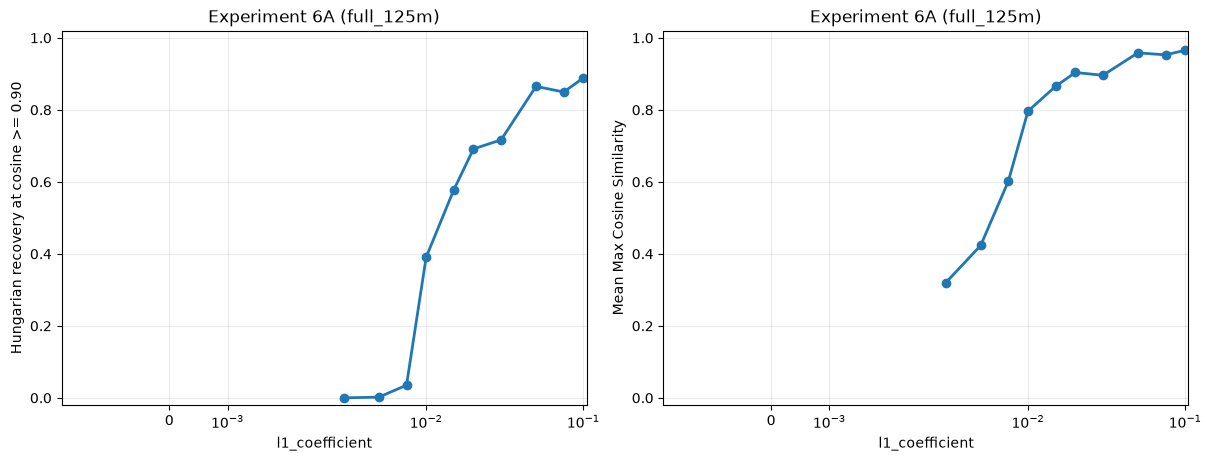

Saved plot: /Users/abdulhakeemadefioye/Desktop/SAE/composed-features/artifacts/06_standard_sae_hyperparameter_sweeps/results/experiment_6a_l1_sweep_full_125m.png
Recommended L1: 0.1
Selection manifest: /Users/abdulhakeemadefioye/Desktop/SAE/composed-features/artifacts/06_standard_sae_hyperparameter_sweeps/results/experiment_6a_l1_selection_full_125m.json


In [8]:
EXPERIMENT_6A_RESULTS_PATH = (
    RESULTS_ROOT / f'experiment_6a_l1_sweep_{RUN_LABEL}.csv'
)
EXPERIMENT_6A_RANKED_PATH = (
    RESULTS_ROOT / f'experiment_6a_l1_sweep_{RUN_LABEL}_ranked.csv'
)
EXPERIMENT_6A_PLOT_PATH = (
    RESULTS_ROOT / f'experiment_6a_l1_sweep_{RUN_LABEL}.png'
)
EXPERIMENT_6A_SELECTION_PATH = (
    RESULTS_ROOT / f'experiment_6a_l1_selection_{RUN_LABEL}.json'
)

results_6a = load_results(EXPERIMENT_6A_RESULTS_PATH)
if RUN_EXPERIMENT_6A:
    results_6a = run_sweep(
        experiment='6A',
        swept_hyperparameter='l1_coefficient',
        candidates=L1_CANDIDATES,
        l1_coefficient=None,
        learning_rate=BASELINE_LEARNING_RATE,
        results_path=EXPERIMENT_6A_RESULTS_PATH,
    )

if not results_6a.empty:
    display(results_6a)
    plot_sweep_results(
        results_6a,
        swept_hyperparameter='l1_coefficient',
        title=f'Experiment 6A ({RUN_LABEL})',
        output_path=EXPERIMENT_6A_PLOT_PATH,
    )

    if all(result_row_exists(results_6a, value) for value in L1_CANDIDATES):
        assert_complete_sweep(results_6a, L1_CANDIDATES, label='Experiment 6A')
        ranked_6a = add_selection_columns(results_6a)
        ranked_6a.to_csv(EXPERIMENT_6A_RANKED_PATH, index=False)
        recommended = recommend_l1(results_6a)
        selection = {
            'experiment': '6A',
            'run_label': RUN_LABEL,
            'selection_rule': (
                'maximize equal-weight mean of hungarian_90 and mmcs; '
                'tie-break by hungarian_90, mmcs, then baseline proximity'
            ),
            'selected_l1_coefficient': float(recommended['l1_coefficient']),
            'hungarian_90': float(recommended['hungarian_90']),
            'mmcs': float(recommended['mmcs']),
            'selection_score': float(recommended['selection_score']),
            'training_samples_per_sae': TRAINING_SAMPLES,
            'train_batch_size': TRAIN_BATCH_SIZE,
            'learning_rate_held_fixed': BASELINE_LEARNING_RATE,
            'l1_candidates': list(L1_CANDIDATES),
        }
        EXPERIMENT_6A_SELECTION_PATH.write_text(
            json.dumps(selection, indent=2) + '\n'
        )
        print('Recommended L1:', selection['selected_l1_coefficient'])
        print('Selection manifest:', EXPERIMENT_6A_SELECTION_PATH)
    else:
        print('6A is incomplete; no L1 selection manifest was written.')
else:
    print(
        'No 6A results yet. Set RUN_EXPERIMENT_6A=True and rerun this cell.'
    )


## Review 6A and resolve the L1 used by 6B

The next cell does no training. It requires the current mode's complete 6A selection
manifest. Leave `SELECTED_L1_OVERRIDE=None` to accept the automatic recommendation,
or set it to one of the tested L1 candidates after inspecting both metrics.


In [9]:
def resolve_selected_l1() -> float:
    if not EXPERIMENT_6A_SELECTION_PATH.is_file():
        raise RuntimeError(
            'Experiment 6A must be completed before resolving the L1 for 6B. '
            f'Missing: {EXPERIMENT_6A_SELECTION_PATH}'
        )
    selection = json.loads(EXPERIMENT_6A_SELECTION_PATH.read_text())
    expected = {
        'run_label': RUN_LABEL,
        'training_samples_per_sae': TRAINING_SAMPLES,
        'train_batch_size': TRAIN_BATCH_SIZE,
        'learning_rate_held_fixed': BASELINE_LEARNING_RATE,
        'l1_candidates': list(L1_CANDIDATES),
    }
    mismatches = {
        key: (selection.get(key), value)
        for key, value in expected.items()
        if selection.get(key) != value
    }
    if mismatches:
        raise ValueError(f'6A selection manifest does not match: {mismatches}')

    selected = (
        float(selection['selected_l1_coefficient'])
        if SELECTED_L1_OVERRIDE is None
        else float(SELECTED_L1_OVERRIDE)
    )
    if not any(
        math.isclose(selected, value, rel_tol=1e-12, abs_tol=1e-15)
        for value in L1_CANDIDATES
    ):
        raise ValueError(
            'SELECTED_L1_OVERRIDE must be one of the completed 6A candidates.'
        )
    return selected


SELECTED_L1_FOR_6B = None
if EXPERIMENT_6A_SELECTION_PATH.is_file():
    try:
        SELECTED_L1_FOR_6B = resolve_selected_l1()
    except ValueError as error:
        if RUN_EXPERIMENT_6B:
            raise
        print('The saved 6A selection is stale for the expanded grid.')
        print('Rerun Experiment 6A before proceeding to 6B:', error)
    else:
        print('L1 fixed for Experiment 6B:', SELECTED_L1_FOR_6B)
else:
    print('Complete Experiment 6A before proceeding to 6B.')


L1 fixed for Experiment 6B: 0.1


# Experiment 6B — Effect of learning rate

Only after reviewing 6A, set `RUN_EXPERIMENT_6B=True` and rerun the constants,
6A-loading, selection-resolution, and 6B cells. Experiment 6B fixes L1 to the
resolved 6A choice and trains a fresh SAE for each learning rate. Its CSV and PNG are
saved after each completed candidate.


,experiment,run_label,swept_hyperparameter,swept_value,l1_coefficient,learning_rate,n_per_set,activation_dim,d_sae,training_samples,train_batch_size,optimizer_steps,dictionary_seed,data_seed,sae_seed,hungarian_90,mmcs
0,6B,full_125m,learning_rate,0.00010,0.1,0.00010,256,256,512,125000000,16384,7630,0,0,0,0.884766,0.965494
1,6B,full_125m,learning_rate,0.00015,0.1,0.00015,256,256,512,125000000,16384,7630,0,0,0,0.892578,0.966674
2,6B,full_125m,learning_rate,0.00020,0.1,0.00020,256,256,512,125000000,16384,7630,0,0,0,0.890625,0.967033
3,6B,full_125m,learning_rate,0.00030,0.1,0.00030,256,256,512,125000000,16384,7630,0,0,0,0.888672,0.965493
4,6B,full_125m,learning_rate,0.00040,0.1,0.00040,256,256,512,125000000,16384,7630,0,0,0,0.900391,0.968989
5,6B,full_125m,learning_rate,0.00050,0.1,0.00050,256,256,512,125000000,16384,7630,0,0,0,0.900391,0.968978
6,6B,full_125m,learning_rate,0.00060,0.1,0.00060,256,256,512,125000000,16384,7630,0,0,0,0.892578,0.966628
7,6B,full_125m,learning_rate,0.00075,0.1,0.00075,256,256,512,125000000,16384,7630,0,0,0,0.890625,0.966974
8,6B,full_125m,learning_rate,0.00100,0.1,0.00100,256,256,512,125000000,16384,7630,0,0,0,0.882812,0.964602
9,6B,full_125m,learning_rate,0.00150,0.1,0.00150,256,256,512,125000000,16384,7630,0,0,0,0.898438,0.969298


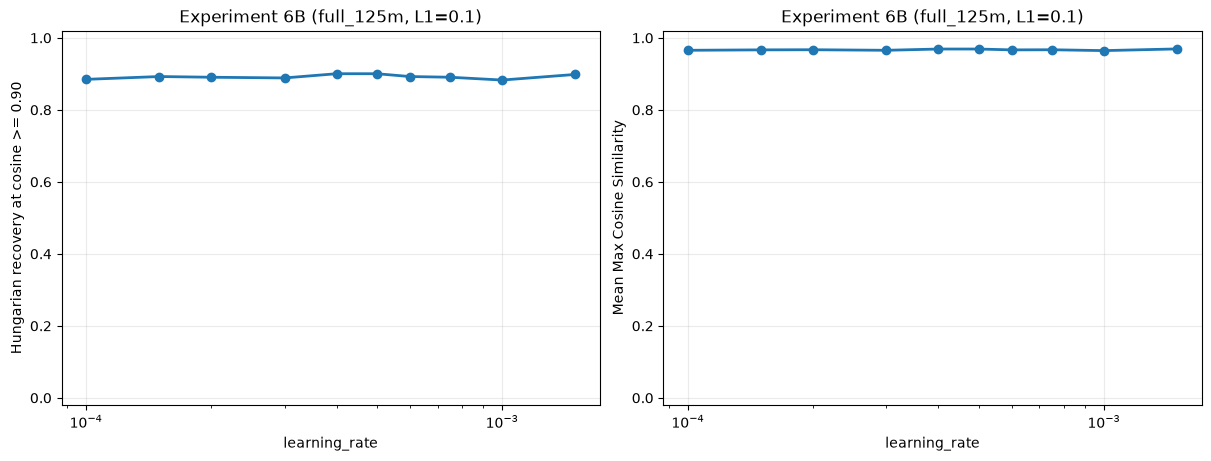

Saved plot: /Users/abdulhakeemadefioye/Desktop/SAE/composed-features/artifacts/06_standard_sae_hyperparameter_sweeps/results/experiment_6b_lr_sweep_full_125m_l1-0p1.png
Recommended learning rate: 0.0004


In [10]:
if RUN_EXPERIMENT_6B and SELECTED_L1_FOR_6B is None:
    raise RuntimeError('Experiment 6B is gated on a complete Experiment 6A.')

if SELECTED_L1_FOR_6B is not None:
    selected_l1_slug = slug_value(SELECTED_L1_FOR_6B)
    EXPERIMENT_6B_RESULTS_PATH = (
        RESULTS_ROOT
        / f'experiment_6b_lr_sweep_{RUN_LABEL}_l1-{selected_l1_slug}.csv'
    )
    EXPERIMENT_6B_PLOT_PATH = (
        RESULTS_ROOT
        / f'experiment_6b_lr_sweep_{RUN_LABEL}_l1-{selected_l1_slug}.png'
    )

    results_6b = load_results(EXPERIMENT_6B_RESULTS_PATH)
    if RUN_EXPERIMENT_6B:
        results_6b = run_sweep(
            experiment='6B',
            swept_hyperparameter='learning_rate',
            candidates=LEARNING_RATE_CANDIDATES,
            l1_coefficient=SELECTED_L1_FOR_6B,
            learning_rate=None,
            results_path=EXPERIMENT_6B_RESULTS_PATH,
        )

    if not results_6b.empty:
        display(results_6b)
        plot_sweep_results(
            results_6b,
            swept_hyperparameter='learning_rate',
            title=(
                f'Experiment 6B ({RUN_LABEL}, '
                f'L1={SELECTED_L1_FOR_6B:g})'
            ),
            output_path=EXPERIMENT_6B_PLOT_PATH,
        )
        if all(
            result_row_exists(results_6b, value)
            for value in LEARNING_RATE_CANDIDATES
        ):
            assert_complete_sweep(
                results_6b,
                LEARNING_RATE_CANDIDATES,
                label='Experiment 6B',
            )
            ranked_6b = add_selection_columns(results_6b)
            ranked_6b.to_csv(
                EXPERIMENT_6B_RESULTS_PATH.with_name(
                    EXPERIMENT_6B_RESULTS_PATH.stem + '_ranked.csv'
                ),
                index=False,
            )
            best_lr = ranked_6b.sort_values(
                ['selection_score', 'hungarian_90', 'mmcs'],
                ascending=False,
            ).iloc[0]
            print('Recommended learning rate:', best_lr['learning_rate'])
    else:
        print(
            'No 6B results yet. After completing 6A, set '
            'RUN_EXPERIMENT_6B=True and rerun this cell.'
        )


## Interpretation and follow-up

For each sweep, first look for settings that are Pareto-optimal on MMCS and Hungarian
90%. The equal-weight score provides one reproducible recommendation, but the two raw
metrics remain the scientific result.

- A high MMCS with lower Hungarian 90% means primitives have nearby decoder
  directions but those directions are not uniquely allocated.
- A high Hungarian 90% means many primitives have distinct, very close decoder
  matches.
- An extreme learning rate that degrades both metrics is evidence of optimization
  failure, not evidence against the ground-truth geometry.

Because each condition uses one initialization, the chosen L1 and learning rate
should eventually be confirmed across several SAE seeds. That replication is outside
Experiments 6A/6B so these sweeps change only one requested hyperparameter at a time.

All outputs are under
`composed-features/artifacts/06_standard_sae_hyperparameter_sweeps/results/`.
